# Profil saisonnier mensuel des passages aux urgences

**Projet data PSL-CFX** — Hôpitaux universitaires Pitié-Salpêtrière / Charles-Foix

## Objectif

Mesurer un profil saisonnier **réel** des passages aux urgences à partir de données
publiques officielles, plutôt que de poser des pourcentages arbitraires. Ce profil
servira ensuite à désaisonnaliser et à projeter l'activité.

Les rapports annuels du groupe hospitalier ne peuvent pas répondre à cette question :
ils ne publient qu'un total annuel, sur des périmètres qui changent d'une année à
l'autre (voir la section « Pièges de comparabilité » du README). Il faut donc une
source à pas fin.

## Source des données

| | |
|---|---|
| **Jeu de données** | Séries longues corrigées du nombre de passages aux urgences 2017 à 2023 en France |
| **Producteur** | DREES — Direction de la recherche, des études, de l'évaluation et des statistiques (ministère de la Santé) |
| **Diffusion** | [data.gouv.fr](https://www.data.gouv.fr/datasets/series-longues-corrigees-du-nombre-de-passages-aux-urgences-2017-a-2023-en-france) |
| **Licence** | Licence Ouverte 2.0 (Etalab) — réutilisation libre avec mention de la source |
| **Période** | 1<sup>er</sup> janvier 2017 au 31 décembre 2023, pas **quotidien** |
| **Granularité** | Département (98 codes présents) |
| **Fichier local** | `data/external/passages_urgences_drees_2017_2023.csv` (7,4 Mo) |

### Méthode de construction de la source

Ces séries ne sont pas des comptages bruts. Les Résumés de Passages aux Urgences
(RPU) remontés par les établissements ont une **couverture incomplète et variable
dans le temps** : tous les services d'urgences ne transmettent pas, et pas toujours
de façon continue. La DREES corrige ce biais par **étalonnage-calage** sur les
totaux de la SAE (Statistique Annuelle des Établissements) et du PMSI, afin
d'obtenir des séries continues et comparables dans le temps.

Conséquence directe : **`nb_passages` contient des valeurs décimales** (par exemple
`397.1`). Ce sont des estimations calées, pas des effectifs. Elles ne doivent pas
être arrondies à l'import, sous peine d'introduire un biais systématique.

> **Note sur le format** : la documentation annonce des dates au format `dd/mm/yyyy`,
> mais le fichier réellement livré utilise le format ISO `yyyy-mm-dd` et le
> séparateur `;`. Le chargement ci-dessous essaie les deux formats et échoue
> bruyamment si aucun ne convient, plutôt que de produire silencieusement des dates
> vides.

## Choix de périmètre géographique

Le fichier est départemental : il ne permet pas d'isoler un établissement. On retient
le **département 75 (Paris)**, où se trouve la Pitié-Salpêtrière (13<sup>e</sup>
arrondissement). L'hypothèse — que la saisonnalité parisienne approche celle du
groupe hospitalier — est testée en fin de notebook par comparaison avec l'Île-de-France
entière.

Charles-Foix est à Ivry-sur-Seine (94) et n'a pas de service d'accueil des urgences :
le périmètre parisien reste donc pertinent pour la question posée.

## 1. Chargement des données

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

%matplotlib inline


def trouver_racine(depart: Path) -> Path:
    """Remonte l'arborescence jusqu'au dossier contenant requirements.txt."""
    for dossier in [depart, *depart.parents]:
        if (dossier / "requirements.txt").exists():
            return dossier
    raise RuntimeError("Racine du projet introuvable")


RACINE = trouver_racine(Path.cwd())
FICHIER_DREES = RACINE / "data" / "external" / "passages_urgences_drees_2017_2023.csv"
DOSSIER_TRAITE = RACINE / "data" / "processed"
DOSSIER_TRAITE.mkdir(parents=True, exist_ok=True)

# Libellés français pour les axes et les tableaux
MOIS_COURTS = ["Janv.", "Févr.", "Mars", "Avr.", "Mai", "Juin",
               "Juil.", "Août", "Sept.", "Oct.", "Nov.", "Déc."]
MOIS_LONGS = ["janvier", "février", "mars", "avril", "mai", "juin",
              "juillet", "août", "septembre", "octobre", "novembre", "décembre"]

print("Fichier source :", FICHIER_DREES.relative_to(RACINE))
print("Présent :", FICHIER_DREES.exists())

Fichier source : data\external\passages_urgences_drees_2017_2023.csv
Présent : True


In [2]:
# Le fichier annoncé en dd/mm/yyyy est en réalité livré en ISO : on essaie les deux.
FORMATS_DATE = ("%Y-%m-%d", "%d/%m/%Y")


def parser_dates(colonne: pd.Series) -> pd.Series:
    """Convertit les dates en testant les formats connus ; échoue si aucun ne convient."""
    for format_date in FORMATS_DATE:
        converti = pd.to_datetime(colonne, format=format_date, errors="coerce")
        if converti.notna().all():
            print(f"Format de date détecté : {format_date}")
            return converti
    raise ValueError(
        f"Aucun format de date connu ne convient (essayés : {', '.join(FORMATS_DATE)})"
    )


# dtype=str sur `dep` pour préserver les zéros initiaux ("01", "75"...)
urgences = pd.read_csv(FICHIER_DREES, sep=";", dtype={"dep": str})
urgences["date"] = parser_dates(urgences["date"])
urgences["annee"] = urgences["date"].dt.year
urgences["mois"] = urgences["date"].dt.month

print(f"\n{len(urgences):,} lignes".replace(",", "\u202f"))
print(f"Période : du {urgences['date'].min():%d/%m/%Y} au {urgences['date'].max():%d/%m/%Y}")
print(f"Départements : {urgences['dep'].nunique()}")
urgences.head()

Format de date détecté : %Y-%m-%d



247 933 lignes
Période : du 01/01/2017 au 31/12/2023
Départements : 98


,date,dep,libelle_dep,nb_passages,annee,mois
0,2017-12-25,61,Orne,397.1,2017,12
1,2018-01-29,61,Orne,429.6,2018,1
2,2018-02-18,61,Orne,378.7,2018,2
3,2018-03-13,61,Orne,385.8,2018,3
4,2018-04-10,61,Orne,352.6,2018,4


## 2. Périmètre retenu et exclusion des années COVID

### Pourquoi exclure 2020 et suivantes du profil « normal »

Le profil saisonnier doit décrire le **fonctionnement habituel** d'un service
d'urgences. Or 2020 et 2021 sont des années atypiques à deux titres :

1. **L'épidémie elle-même** déforme la saisonnalité (vagues épidémiques hors du
   rythme habituel des viroses hivernales).
2. **Les confinements et le renoncement aux soins** ont fait chuter la fréquentation
   pour des motifs sans rapport avec la santé : en avril 2020, Paris n'enregistre
   que 54 % des passages d'un mois d'avril normal.

Retenir ces années reviendrait à intégrer un choc exceptionnel dans une référence
censée représenter la normale. On construit donc le profil sur **2017, 2018 et 2019**,
soit trois années pleines pré-COVID.

> **Les années 2020 à 2023 ne sont pas supprimées pour autant** : le fichier complet
> reste dans `data/external/`. Elles serviront à l'étape « scénario de crise » pour
> **mesurer** l'impact réel du COVID (ratio mois par mois entre 2020 et la moyenne
> 2017-2019), au lieu de le supposer.

In [3]:
DEPARTEMENT_PARIS = "75"
ANNEES_NORMALES = [2017, 2018, 2019]

paris = urgences[urgences["dep"] == DEPARTEMENT_PARIS].copy()
paris_normal = paris[paris["annee"].isin(ANNEES_NORMALES)].copy()

# Contrôle de complétude : 3 années pleines = 1095 jours (aucune bissextile ici)
jours_attendus = 365 * len(ANNEES_NORMALES)
jours_observes = paris_normal["date"].nunique()

print(f"Département retenu : {DEPARTEMENT_PARIS} "
      f"({paris['libelle_dep'].iloc[0]})")
print(f"Jours couverts 2017-2019 : {jours_observes} / {jours_attendus} attendus")
assert jours_observes == jours_attendus, "Jours manquants dans la période de référence"

print("\nVolume annuel de passages :")
for annee, groupe in paris.groupby("annee"):
    marque = "  (référence)" if annee in ANNEES_NORMALES else ""
    total = groupe["nb_passages"].sum()
    print(f"  {annee} : {total:>12,.0f} passages{marque}".replace(",", "\u202f"))

Département retenu : 75 (Paris)
Jours couverts 2017-2019 : 1095 / 1095 attendus

Volume annuel de passages :
  2017 :      911 989 passages  (référence)
  2018 :      935 615 passages  (référence)
  2019 :      924 264 passages  (référence)
  2020 :      742 410 passages
  2021 :      796 090 passages
  2022 :      820 552 passages
  2023 :      762 779 passages


## 3. Construction du profil : deux mesures complémentaires

Le profil est calculé de deux façons, qui ne disent pas la même chose :

- **`PCT_NORMAL`** — part de chaque mois dans le total annuel. Calculée année par
  année puis moyennée sur 2017-2019, elle somme à 100. C'est la mesure utile pour
  répartir un volume annuel prévu entre les douze mois.
- **`PASSAGES_MOYENS_PAR_JOUR`** — nombre moyen de passages par jour du mois. C'est
  la mesure de l'**intensité réelle** de l'activité, indépendante du calendrier.

In [4]:
# --- Mesure 1 : part de chaque mois dans le total de son année ---
# On calcule la part année par année AVANT de moyenner, pour qu'une année de fort
# volume ne pèse pas davantage qu'une autre dans le profil moyen.
parts_par_annee = []
for annee, groupe in paris_normal.groupby("annee"):
    totaux_mensuels = groupe.groupby("mois")["nb_passages"].sum()
    parts_par_annee.append(totaux_mensuels / totaux_mensuels.sum() * 100)

parts = pd.concat(parts_par_annee, axis=1)
parts.columns = ANNEES_NORMALES
pct_normal = parts.mean(axis=1)

# --- Mesure 2 : passages moyens par jour ---
# Le nombre de jours est compté sur les données elles-mêmes, pas supposé.
agregat = paris_normal.groupby("mois").agg(
    total_passages=("nb_passages", "sum"),
    nb_jours=("date", "nunique"),
)
passages_par_jour = agregat["total_passages"] / agregat["nb_jours"]

profil = pd.DataFrame({
    "MOIS": range(1, 13),
    "PCT_NORMAL": pct_normal.values,
    "PASSAGES_MOYENS_PAR_JOUR": passages_par_jour.values,
})
profil.insert(1, "LIBELLE_MOIS", MOIS_LONGS)
profil["NB_JOURS_OBSERVES"] = agregat["nb_jours"].values

print(f"Somme des parts mensuelles : {profil['PCT_NORMAL'].sum():.4f} %")
profil.round(2)

Somme des parts mensuelles : 100.0000 %


,MOIS,LIBELLE_MOIS,PCT_NORMAL,PASSAGES_MOYENS_PAR_JOUR,NB_JOURS_OBSERVES
0,1,janvier,8.65,2578.90,93
1,2,février,7.66,2528.21,84
2,3,mars,8.54,2545.97,93
3,4,avril,8.14,2506.56,90
4,5,mai,8.47,2525.65,93
5,6,juin,8.45,2600.81,90
6,7,juillet,8.12,2419.75,93
7,8,août,7.19,2141.84,93
8,9,septembre,8.13,2502.85,90
9,10,octobre,8.98,2675.40,93


In [5]:
# Identification des pics et des creux, calculée sur les données (rien n'est supposé)
mois_pic_part = int(profil.loc[profil["PCT_NORMAL"].idxmax(), "MOIS"])
mois_creux_part = int(profil.loc[profil["PCT_NORMAL"].idxmin(), "MOIS"])
mois_pic_jour = int(profil.loc[profil["PASSAGES_MOYENS_PAR_JOUR"].idxmax(), "MOIS"])
mois_creux_jour = int(profil.loc[profil["PASSAGES_MOYENS_PAR_JOUR"].idxmin(), "MOIS"])

moyenne_jour = profil["PASSAGES_MOYENS_PAR_JOUR"].mean()

print("En part du total annuel :")
print(f"  pic   : {MOIS_LONGS[mois_pic_part - 1]} "
      f"({profil['PCT_NORMAL'].max():.2f} %)")
print(f"  creux : {MOIS_LONGS[mois_creux_part - 1]} "
      f"({profil['PCT_NORMAL'].min():.2f} %)")

print("\nEn passages moyens par jour :")
print(f"  pic   : {MOIS_LONGS[mois_pic_jour - 1]} "
      f"({profil['PASSAGES_MOYENS_PAR_JOUR'].max():,.0f} par jour, "
      f"{profil['PASSAGES_MOYENS_PAR_JOUR'].max() / moyenne_jour - 1:+.1%} vs moyenne)"
      .replace(",", "\u202f"))
print(f"  creux : {MOIS_LONGS[mois_creux_jour - 1]} "
      f"({profil['PASSAGES_MOYENS_PAR_JOUR'].min():,.0f} par jour, "
      f"{profil['PASSAGES_MOYENS_PAR_JOUR'].min() / moyenne_jour - 1:+.1%} vs moyenne)"
      .replace(",", "\u202f"))

# Février illustre le mieux l'écart entre les deux lectures
rang_part_fevrier = int(profil["PCT_NORMAL"].rank(ascending=True)[1])
rang_jour_fevrier = int(profil["PASSAGES_MOYENS_PAR_JOUR"].rank(ascending=True)[1])
print(f"\nFévrier : {rang_part_fevrier}e mois le plus faible en part du total annuel, "
      f"mais {rang_jour_fevrier}e en intensité quotidienne.")

En part du total annuel :
  pic   : octobre (8.98 %)
  creux : août (7.19 %)

En passages moyens par jour :
  pic   : novembre (2 713 par jour  +7.1% vs moyenne)
  creux : août (2 142 par jour  -15.4% vs moyenne)

Février : 2e mois le plus faible en part du total annuel, mais 6e en intensité quotidienne.


### Effet de la longueur des mois

Les deux lectures diffèrent parce que la part du total annuel dépend mécaniquement
du nombre de jours du mois : **février apparaît comme un creux (7,7 % de l'année)
alors que son intensité quotidienne est proche de la moyenne** — son déficit n'est
qu'un effet de calendrier, que la vue « par jour » corrige. Le même décalage explique
que le pic soit en octobre (31 jours) en part annuelle, mais en novembre (30 jours)
en intensité réelle.

## 4. Graphique du profil saisonnier

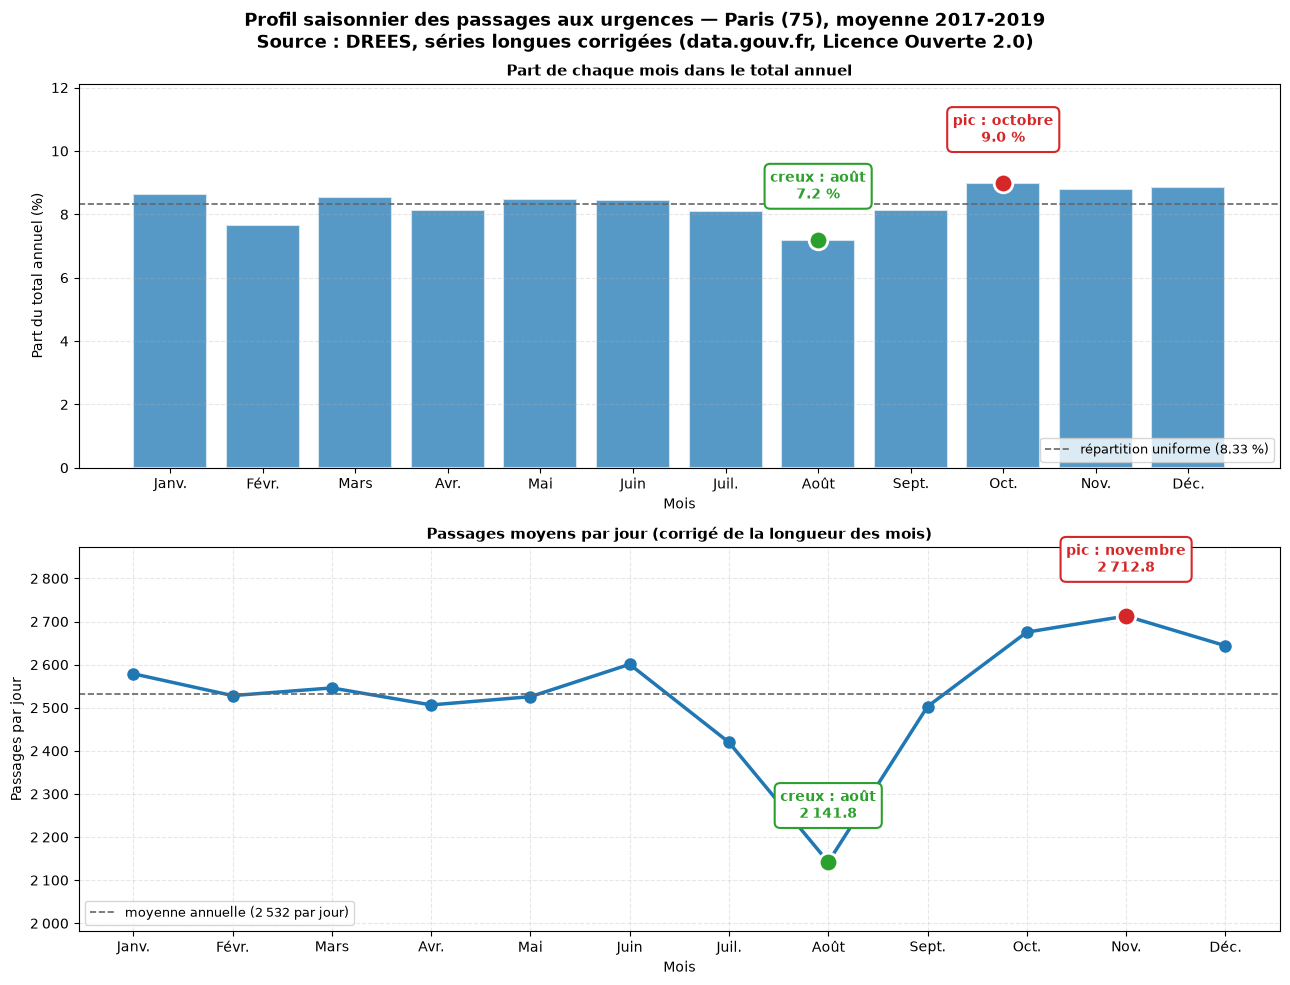

In [6]:
formateur_milliers = FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "\u202f"))

BLEU = "#1f77b4"
ROUGE = "#d62728"
VERT = "#2ca02c"

fig, (ax_haut, ax_bas) = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle(
    "Profil saisonnier des passages aux urgences — Paris (75), moyenne 2017-2019\n"
    "Source : DREES, séries longues corrigées (data.gouv.fr, Licence Ouverte 2.0)",
    fontsize=13, fontweight="bold",
)


def annoter_extremes(ax, valeurs, mois_pic, mois_creux, suffixe, decalage):
    """Met en évidence le mois le plus haut et le plus bas de la série."""
    for mois, couleur, etiquette in [(mois_pic, ROUGE, "pic"), (mois_creux, VERT, "creux")]:
        valeur = valeurs[mois - 1]
        ax.scatter([mois], [valeur], s=180, zorder=5, color=couleur,
                   edgecolor="white", linewidth=2)
        ax.annotate(
            f"{etiquette} : {MOIS_LONGS[mois - 1]}\n{valeur:,.1f}{suffixe}".replace(",", "\u202f"),
            xy=(mois, valeur), xytext=(0, decalage), textcoords="offset points",
            ha="center", fontsize=10, fontweight="bold", color=couleur,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor=couleur, linewidth=1.5),
        )


# --- Panneau du haut : part du total annuel ---
ax_haut.bar(profil["MOIS"], profil["PCT_NORMAL"], color=BLEU, alpha=0.75,
            edgecolor="white", linewidth=1.5)
ax_haut.axhline(100 / 12, color="#666666", linestyle="--", linewidth=1.2,
                label=f"répartition uniforme ({100 / 12:.2f} %)")
annoter_extremes(ax_haut, profil["PCT_NORMAL"].tolist(),
                 mois_pic_part, mois_creux_part, " %", 30)

ax_haut.set_title("Part de chaque mois dans le total annuel", fontsize=11, fontweight="bold")
ax_haut.set_xlabel("Mois")
ax_haut.set_ylabel("Part du total annuel (%)")
ax_haut.set_xticks(range(1, 13))
ax_haut.set_xticklabels(MOIS_COURTS)
ax_haut.set_ylim(0, profil["PCT_NORMAL"].max() * 1.35)
ax_haut.legend(loc="lower right", fontsize=9)
ax_haut.grid(axis="y", alpha=0.3, linestyle="--")

# --- Panneau du bas : intensité quotidienne ---
ax_bas.plot(profil["MOIS"], profil["PASSAGES_MOYENS_PAR_JOUR"], marker="o",
            markersize=8, linewidth=2.5, color=BLEU)
ax_bas.axhline(moyenne_jour, color="#666666", linestyle="--", linewidth=1.2,
               label=f"moyenne annuelle ({moyenne_jour:,.0f} par jour)".replace(",", "\u202f"))
annoter_extremes(ax_bas, profil["PASSAGES_MOYENS_PAR_JOUR"].tolist(),
                 mois_pic_jour, mois_creux_jour, "", 32)

ax_bas.set_title("Passages moyens par jour (corrigé de la longueur des mois)",
                 fontsize=11, fontweight="bold")
ax_bas.set_xlabel("Mois")
ax_bas.set_ylabel("Passages par jour")
ax_bas.set_xticks(range(1, 13))
ax_bas.set_xticklabels(MOIS_COURTS)
ax_bas.yaxis.set_major_formatter(formateur_milliers)
ax_bas.margins(y=0.28)
ax_bas.legend(loc="lower left", fontsize=9)
ax_bas.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

## 5. Sensibilité : Paris seul ou Île-de-France entière ?

Retenir le seul département 75 est un choix. On le teste en recalculant le profil sur
les huit départements franciliens (75, 77, 78, 91, 92, 93, 94, 95) : si les deux
profils se superposent, le choix de Paris seul n'introduit pas de biais saisonnier.

In [7]:
DEPARTEMENTS_IDF = ["75", "77", "78", "91", "92", "93", "94", "95"]

idf_normal = urgences[
    urgences["dep"].isin(DEPARTEMENTS_IDF) & urgences["annee"].isin(ANNEES_NORMALES)
]

# Contrôle : les huit départements sont bien présents dans la source
departements_trouves = sorted(idf_normal["dep"].unique())
assert departements_trouves == sorted(DEPARTEMENTS_IDF), \
    f"Départements manquants : {set(DEPARTEMENTS_IDF) - set(departements_trouves)}"

parts_idf_par_annee = []
for annee, groupe in idf_normal.groupby("annee"):
    totaux_mensuels = groupe.groupby("mois")["nb_passages"].sum()
    parts_idf_par_annee.append(totaux_mensuels / totaux_mensuels.sum() * 100)

pct_idf = pd.concat(parts_idf_par_annee, axis=1).mean(axis=1)

comparaison = pd.DataFrame({
    "MOIS": range(1, 13),
    "LIBELLE_MOIS": MOIS_LONGS,
    "PARIS_75": pct_normal.values,
    "ILE_DE_FRANCE": pct_idf.values,
})
comparaison["ECART_POINTS"] = comparaison["PARIS_75"] - comparaison["ILE_DE_FRANCE"]

ecart_max = comparaison["ECART_POINTS"].abs().max()
correlation = comparaison["PARIS_75"].corr(comparaison["ILE_DE_FRANCE"])
mois_ecart_max = comparaison.loc[comparaison["ECART_POINTS"].abs().idxmax(), "LIBELLE_MOIS"]

print(f"Écart absolu maximal : {ecart_max:.3f} point de pourcentage (en {mois_ecart_max})")
print(f"Corrélation des deux profils : {correlation:.4f}")
print(f"Volume de référence : Paris {paris_normal['nb_passages'].sum():,.0f} passages "
      f"contre {idf_normal['nb_passages'].sum():,.0f} pour l'Île-de-France"
      .replace(",", "\u202f"))
comparaison.round(3)

Écart absolu maximal : 0.262 point de pourcentage (en décembre)
Corrélation des deux profils : 0.9831
Volume de référence : Paris 2 771 868 passages contre 13 422 649 pour l'Île-de-France


,MOIS,LIBELLE_MOIS,PARIS_75,ILE_DE_FRANCE,ECART_POINTS
0,1,janvier,8.651,8.749,-0.097
1,2,février,7.661,7.638,0.023
2,3,mars,8.542,8.514,0.028
3,4,avril,8.137,8.172,-0.035
4,5,mai,8.475,8.492,-0.018
5,6,juin,8.446,8.456,-0.010
6,7,juillet,8.118,8.018,0.099
7,8,août,7.187,7.139,0.048
8,9,septembre,8.126,8.126,-0.000
9,10,octobre,8.977,8.882,0.095


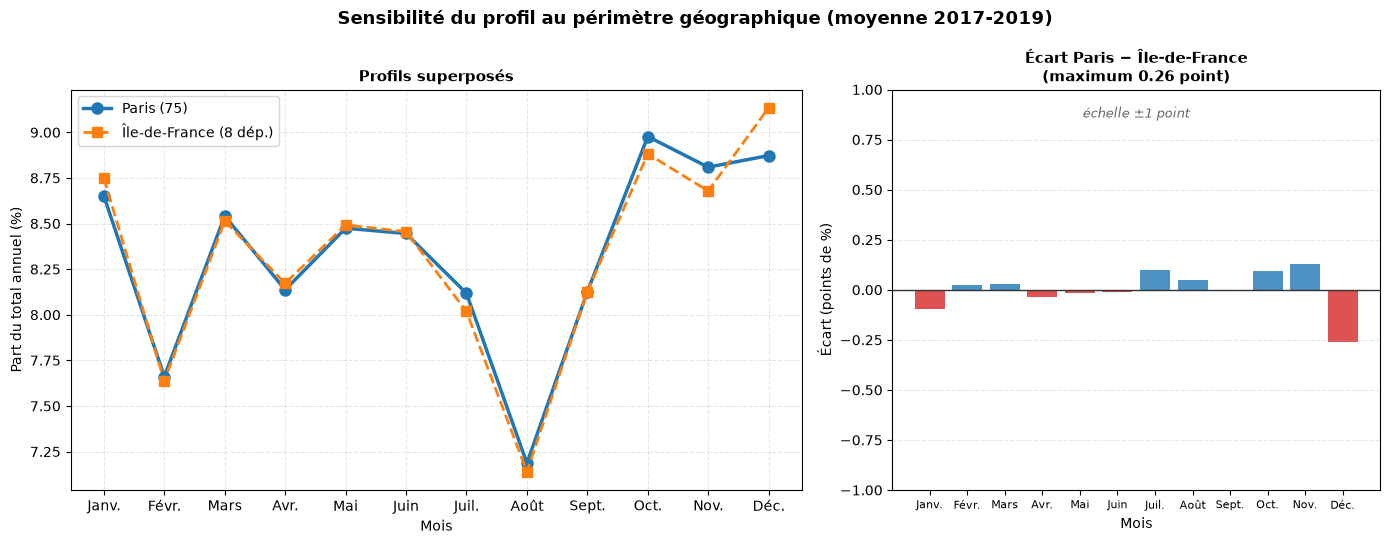

In [8]:
fig, (ax_gauche, ax_droite) = plt.subplots(1, 2, figsize=(14, 5.5),
                                           gridspec_kw={"width_ratios": [3, 2]})
fig.suptitle("Sensibilité du profil au périmètre géographique (moyenne 2017-2019)",
             fontsize=13, fontweight="bold")

# Superposition des deux profils
ax_gauche.plot(comparaison["MOIS"], comparaison["PARIS_75"], marker="o", markersize=8,
               linewidth=2.5, color=BLEU, label="Paris (75)")
ax_gauche.plot(comparaison["MOIS"], comparaison["ILE_DE_FRANCE"], marker="s", markersize=7,
               linewidth=2, color="#ff7f0e", linestyle="--", label="Île-de-France (8 dép.)")
ax_gauche.set_title("Profils superposés", fontsize=11, fontweight="bold")
ax_gauche.set_xlabel("Mois")
ax_gauche.set_ylabel("Part du total annuel (%)")
ax_gauche.set_xticks(range(1, 13))
ax_gauche.set_xticklabels(MOIS_COURTS)
ax_gauche.legend(fontsize=10)
ax_gauche.grid(alpha=0.3, linestyle="--")

# Écart mois par mois, à l'échelle du dixième de point
couleurs_ecart = [ROUGE if e < 0 else BLEU for e in comparaison["ECART_POINTS"]]
ax_droite.bar(comparaison["MOIS"], comparaison["ECART_POINTS"], color=couleurs_ecart, alpha=0.8)
ax_droite.axhline(0, color="#333333", linewidth=1)
ax_droite.set_title(f"Écart Paris − Île-de-France\n(maximum {ecart_max:.2f} point)",
                    fontsize=11, fontweight="bold")
ax_droite.set_xlabel("Mois")
ax_droite.set_ylabel("Écart (points de %)")
ax_droite.set_xticks(range(1, 13))
ax_droite.set_xticklabels(MOIS_COURTS, fontsize=8)
ax_droite.set_ylim(-1, 1)
ax_droite.grid(axis="y", alpha=0.3, linestyle="--")
ax_droite.text(0.5, 0.93, "échelle ±1 point", transform=ax_droite.transAxes,
               ha="center", fontsize=9, style="italic", color="#666666")

plt.tight_layout()
plt.show()

### Justification du choix

Les deux profils sont pratiquement confondus : l'écart mensuel maximal atteint
**0,26 point de pourcentage** (en décembre) et la corrélation entre les deux séries
est de **0,983**. Élargir le périmètre à l'Île-de-France ne changerait donc pas la
forme de la saisonnalité, tout en diluant Paris dans des départements dont le
recrutement hospitalier n'a rien à voir avec celui de la Pitié-Salpêtrière.

On conserve **Paris seul**, périmètre le plus proche géographiquement de
l'établissement, en sachant que le résultat est robuste à ce choix.

## 6. Enregistrement du profil

In [9]:
destination = DOSSIER_TRAITE / "profil_saisonnier.csv"

# Les trois colonnes demandées ; les libellés de mois et le nombre de jours
# observés sont conservés car ils facilitent la relecture du fichier.
profil_final = profil[["MOIS", "PCT_NORMAL", "PASSAGES_MOYENS_PAR_JOUR"]].copy()
profil_final["PCT_NORMAL"] = profil_final["PCT_NORMAL"].round(4)
profil_final["PASSAGES_MOYENS_PAR_JOUR"] = profil_final["PASSAGES_MOYENS_PAR_JOUR"].round(2)

profil_final.to_csv(destination, index=False, encoding="utf-8")

# Contrôles finaux avant de clore l'étape
assert len(profil_final) == 12, "Le profil doit compter 12 mois"
assert abs(profil_final["PCT_NORMAL"].sum() - 100) < 0.01, "Les parts doivent sommer à 100"
assert profil_final["PASSAGES_MOYENS_PAR_JOUR"].gt(0).all(), "Valeurs quotidiennes invalides"

print(f"Écrit dans {destination.relative_to(RACINE)}")
print(f"Somme des parts : {profil_final['PCT_NORMAL'].sum():.4f} %")
profil_final

Écrit dans data\processed\profil_saisonnier.csv
Somme des parts : 99.9999 %


,MOIS,PCT_NORMAL,PASSAGES_MOYENS_PAR_JOUR
0,1,8.6513,2578.90
1,2,7.6610,2528.21
2,3,8.5417,2545.97
3,4,8.1369,2506.56
4,5,8.4745,2525.65
5,6,8.4457,2600.81
6,7,8.1175,2419.75
7,8,7.1866,2141.84
8,9,8.1259,2502.85
9,10,8.9770,2675.40


## 7. Conclusion

**La saisonnalité des urgences parisiennes est réelle mais modérée.** Mesurée sur
trois années pré-COVID, l'amplitude va de **2 142 passages par jour en août** à
**2 713 en novembre**, soit un écart de 27 % entre le mois le plus creux et le plus
chargé. Rapporté à la moyenne annuelle (2 531 par jour), août est à −15 % et novembre
à +7 % : le creux estival est nettement plus marqué que le pic hivernal.

**La forme du profil est un creux d'été, pas un pic d'hiver.** Les mois d'octobre à
janvier se tiennent tous entre 2 579 et 2 713 passages par jour, sans pic isolé ;
c'est août qui décroche franchement, suivi de juillet. La lecture spontanée
« épidémies hivernales = pic des urgences » n'est pas ce que montrent les données à
l'échelle mensuelle.

**Les deux mesures du profil ne sont pas interchangeables.** En part du total annuel,
février semble le deuxième mois le plus faible ; en intensité quotidienne, il est dans
la moyenne. L'écart tient uniquement à ses 28 jours. Utiliser `PCT_NORMAL` pour
répartir un volume annuel est correct ; l'utiliser pour comparer l'intensité de deux
mois ne l'est pas.

**Le résultat ne dépend pas du découpage géographique.** Le profil francilien est
quasi identique à celui de Paris (écart maximal 0,26 point, corrélation 0,983), ce qui
donne confiance dans l'usage du seul département 75 comme approximation du bassin de
recrutement de la Pitié-Salpêtrière.

**Ce profil remplace une hypothèse par une mesure.** C'est le point méthodologique de
cette étape : la répartition mensuelle n'est plus posée arbitrairement mais estimée sur
2,8 millions de passages réels. Les années 2020 à 2023, conservées dans
`data/external/`, permettront à l'étape suivante de mesurer l'ampleur du choc COVID
plutôt que de la supposer — à titre indicatif, avril 2020 n'atteint que 54 % d'un mois
d'avril normal à Paris.